In [1]:
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.circuit.library import efficient_su2
from scipy.optimize import minimize

from src.checker import evaluate_vqe_pair
# Core libraries
import qiskit
from qiskit import QuantumCircuit
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Project modules
from src.runners import run_circuit
from src.transformations import (
    identity_transformation,
    barrier_only,
    commute_independent,
)
from src.checker import (
    check_violation,
    print_comparison,
)

print("All imports successful.")
print("Qiskit version:", qiskit.__version__)

All imports successful.
Qiskit version: 2.3.0


In [2]:
SHOTS = 10000
SEED = 42

results = []

def record_result(test_name, tvd_dist, violation, p_value, chi2_stat):
    results.append({
        "test": test_name,
        "tvd": tvd_dist,
        "p_value": p_value,
        "chi2_stat": chi2_stat,
        "violation": violation,
    })

def run_and_check(test_name, qc_source, qc_follow, tvd_threshold=0.05, chi_alpha=0.05):
    counts_source = run_circuit(qc_source, shots=SHOTS, seed=SEED)
    counts_follow = run_circuit(qc_follow, shots=SHOTS, seed=SEED)

    tvd_viol, tvd_dist, chi_viol, p_val, chi2_stat = check_violation(
        counts_source,
        counts_follow,
        tvd_threshold=tvd_threshold,
        chi_alpha=chi_alpha,
    )

    violation = tvd_viol or chi_viol

    print(f"{test_name}")
    print(f"TVD: {tvd_dist:.4f}")
    print(f"p-value: {p_val:.6f}")
    print(f"chi2 statistic: {chi2_stat:.4f}")
    print(f"Violation: {violation}\n")

    record_result(test_name, tvd_dist, violation, p_val, chi2_stat)
    print_comparison(counts_source, counts_follow)

    return counts_source, counts_follow

# 1. Bell state – identity transformation

In [3]:
print("=== Identity Transformation Test ===\n")

qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.measure_all()

qc_follow = identity_transformation(qc, seed=SEED)

run_and_check(
    test_name="identity",
    qc_source=qc,
    qc_follow=qc_follow,
)

=== Identity Transformation Test ===

identity
TVD: 0.0000
p-value: 1.000000
chi2 statistic: 0.0000
Violation: False


State | Source Prob | Follow-up Prob | Diff
--------------------------------------------
   00 |      0.4932 |         0.4932 | 0.0000
   11 |      0.5068 |         0.5068 | 0.0000


({'11': 5068, '00': 4932}, {'11': 5068, '00': 4932})

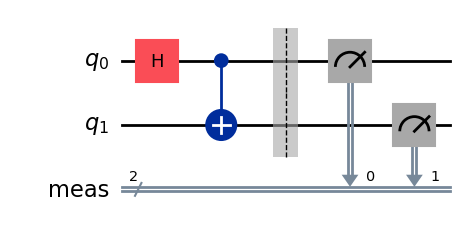

In [4]:
qc.draw("mpl")

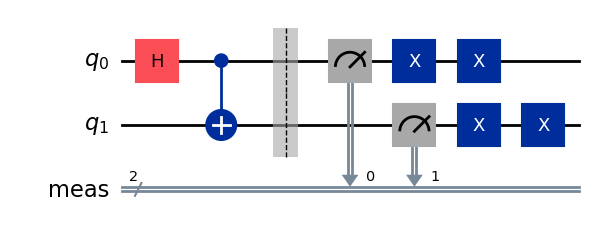

In [5]:
qc_follow.draw("mpl")

# 2. Intentional violation – flip X gate

In [6]:
print("\n=== Weak Fault Example ===\n")

qc_source = QuantumCircuit(2)
qc_source.h(0)
qc_source.cx(0, 1)
qc_source.measure_all()

qc_fault = QuantumCircuit(2)
qc_fault.h(0)
qc_fault.cx(0, 1)
qc_fault.x(0)
qc_fault.measure_all()

run_and_check(
    test_name="weak_fault_single_x",
    qc_source=qc_source,
    qc_follow=qc_fault,
)


=== Weak Fault Example ===

weak_fault_single_x
TVD: 1.0000
p-value: 0.000000
chi2 statistic: 20000.0000
Violation: True


State | Source Prob | Follow-up Prob | Diff
--------------------------------------------
   00 |      0.4932 |         0.0000 | 0.4932
   01 |      0.0000 |         0.5068 | 0.5068
   10 |      0.0000 |         0.4932 | 0.4932
   11 |      0.5068 |         0.0000 | 0.5068


({'11': 5068, '00': 4932}, {'01': 5068, '10': 4932})

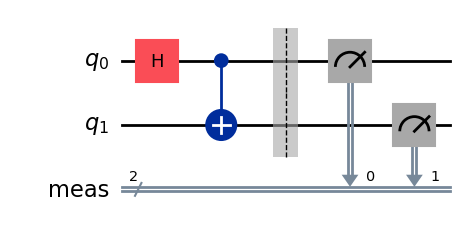

In [7]:
qc.draw("mpl")


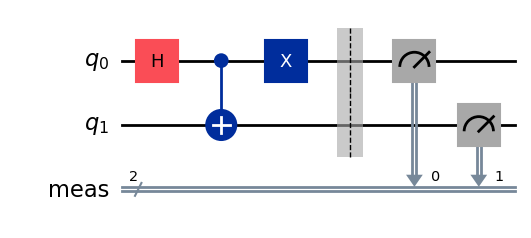

In [9]:
qc_fault.draw("mpl")

In [10]:
print("\n=== Strong Fault Example ===\n")

qc_source = QuantumCircuit(2)
qc_source.h(0)
qc_source.cx(0, 1)
qc_source.measure_all()

qc_fault = QuantumCircuit(2)
qc_fault.h(0)
qc_fault.cx(0, 1)
qc_fault.cx(1, 0)  
qc_fault.measure_all()

run_and_check(
    test_name="strong_fault_double_x",
    qc_source=qc_source,
    qc_follow=qc_fault,
)


=== Strong Fault Example ===

strong_fault_double_x
TVD: 0.5068
p-value: 0.000000
chi2 statistic: 10052.7093
Violation: True


State | Source Prob | Follow-up Prob | Diff
--------------------------------------------
   00 |      0.4932 |         0.5016 | 0.0084
   10 |      0.0000 |         0.4984 | 0.4984
   11 |      0.5068 |         0.0000 | 0.5068


({'11': 5068, '00': 4932}, {'00': 5016, '10': 4984})

# 3. Barrier insertion

In [11]:
print("\n=== Barrier Test ===\n")

qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.measure_all()

qc_barrier = barrier_only(qc, seed=SEED)

run_and_check(
    test_name="barrier",
    qc_source=qc,
    qc_follow=qc_barrier,
)


=== Barrier Test ===

barrier
TVD: 0.0000
p-value: 1.000000
chi2 statistic: 0.0000
Violation: False


State | Source Prob | Follow-up Prob | Diff
--------------------------------------------
   00 |      0.4932 |         0.4932 | 0.0000
   11 |      0.5068 |         0.5068 | 0.0000


({'11': 5068, '00': 4932}, {'11': 5068, '00': 4932})

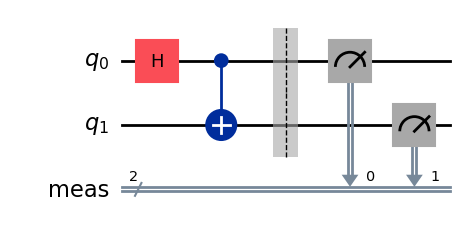

In [12]:
qc.draw('mpl')


Barrier-inserted circuit:


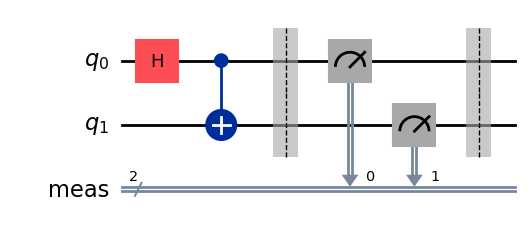

In [13]:
print("\nBarrier-inserted circuit:")
qc_barrier.draw('mpl')


# 4. Commutation of independent gates test

In [14]:
print("\n=== Commutation Test ===\n")

qc = QuantumCircuit(3)
qc.h(0)
qc.x(1)
qc.z(2)
qc.cx(0, 2)
qc.measure_all()

qc_follow = commute_independent(qc, seed=SEED)

run_and_check(
    test_name="commute",
    qc_source=qc,
    qc_follow=qc_follow,
)


=== Commutation Test ===

commute
TVD: 0.0000
p-value: 1.000000
chi2 statistic: 0.0000
Violation: False


State | Source Prob | Follow-up Prob | Diff
--------------------------------------------
  010 |      0.4932 |         0.4932 | 0.0000
  111 |      0.5068 |         0.5068 | 0.0000


({'111': 5068, '010': 4932}, {'111': 5068, '010': 4932})

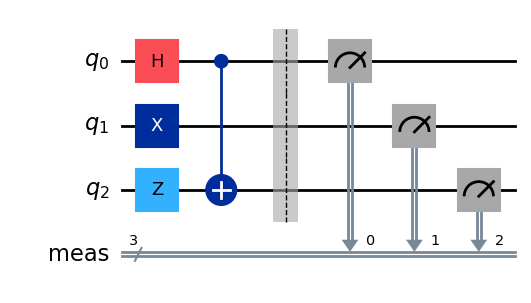

In [15]:
qc.draw('mpl')   

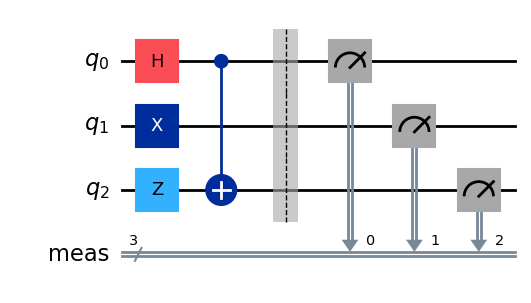

In [16]:
qc_follow.draw('mpl')


In [17]:
df_results = pd.DataFrame(results)
display(df_results)

,test,tvd,p_value,chi2_stat,violation
0,identity,0.0000,1.0,0.000000,False
1,weak_fault_single_x,1.0000,0.0,20000.000000,True
2,strong_fault_double_x,0.5068,0.0,10052.709288,True
3,barrier,0.0000,1.0,0.000000,False
4,commute,0.0000,1.0,0.000000,False


In [18]:
print("\n=== Minimal VQE Example ===\n")

H = SparsePauliOp(["ZZ", "IX", "XI"], coeffs=[-1.0, 0.5, 0.5])

def energy(ansatz, params):
    bound = ansatz.assign_parameters(params)
    sv = Statevector.from_instruction(bound)
    return float(np.real(sv.expectation_value(H)))

def run_vqe_trace(ansatz, initial_point, maxiter=30):
    trace_rows = []

    def objective(params):
        e = energy(ansatz, params)

        # simple placeholder symmetry-like value for toy example
        # if you have a better observable, use it instead
        sym_val = e

        trace_rows.append({
            "eval": len(trace_rows),
            "energy": e,
            "symmetry": sym_val,
            "params": np.array(params, dtype=float),
        })
        return e

    result = minimize(
        objective,
        initial_point,
        method="COBYLA",
        options={"maxiter": maxiter},
    )

    trace_df = pd.DataFrame(trace_rows)
    return result, trace_df


=== Minimal VQE Example ===



In [19]:
ansatz = efficient_su2(2, reps=2, entanglement="full")

ansatz_id = ansatz.copy()
ansatz_id.x(0)
ansatz_id.x(0)

rng = np.random.default_rng(SEED)
initial_point = rng.uniform(-0.1, 0.1, ansatz.num_parameters)

res_src, trace_src = run_vqe_trace(ansatz, initial_point)
res_id, trace_id = run_vqe_trace(ansatz_id, initial_point)

metrics = evaluate_vqe_pair(
    source_result=res_src,
    follow_result=res_id,
    source_trace=trace_src,
    follow_trace=trace_id,
    energy_threshold=1e-3,
    symmetry_threshold=1e-3,
    param_threshold=1e-2,
)

print("Identity relation metrics:")
for k, v in metrics.items():
    if k != "params":
        print(f"{k}: {v}")

Identity relation metrics:
violation: False
delta_E: 0.0
energy_violation: False
symmetry_violation: False
param_violation: False
avg_energy_diff: 0.0
max_energy_diff: 0.0
avg_sym_diff: 0.0
max_sym_diff: 0.0
avg_param_diff: 0.0
max_param_diff: 0.0
trace_len: 30
param_dim_mismatch: False


In [20]:
ansatz_fault = ansatz.copy()
ansatz_fault.x(0)

res_fault, trace_fault = run_vqe_trace(ansatz_fault, initial_point)

metrics_fault = evaluate_vqe_pair(
    source_result=res_src,
    follow_result=res_fault,
    source_trace=trace_src,
    follow_trace=trace_fault,
    energy_threshold=1e-3,
    symmetry_threshold=1e-3,
    param_threshold=1e-2,
)

print("Fault relation metrics:")
for k, v in metrics_fault.items():
    if k != "params":
        print(f"{k}: {v}")

Fault relation metrics:
violation: True
delta_E: 0.02855543686643225
energy_violation: True
symmetry_violation: True
param_violation: True
avg_energy_diff: 0.6251271428941401
max_energy_diff: 1.9941484072442621
avg_sym_diff: 0.6251271428941401
max_sym_diff: 1.9941484072442621
avg_param_diff: 2.0593255060028826
max_param_diff: 3.2001366971504797
trace_len: 30
param_dim_mismatch: False
